# AI & ML Course with BinX — Week 1 — Day 5 —  Matplotlib & Week 1 Mini-Notebook 

## 5.1 Why Visualization Matters

Numbers in a table hide patterns that a chart reveals instantly — trends,
clusters, outliers, and relationships between variables. Visualization is
both an exploration tool (understanding data during analysis) and a
communication tool (explaining findings to others).

## 5.2 The Matplotlib Basics

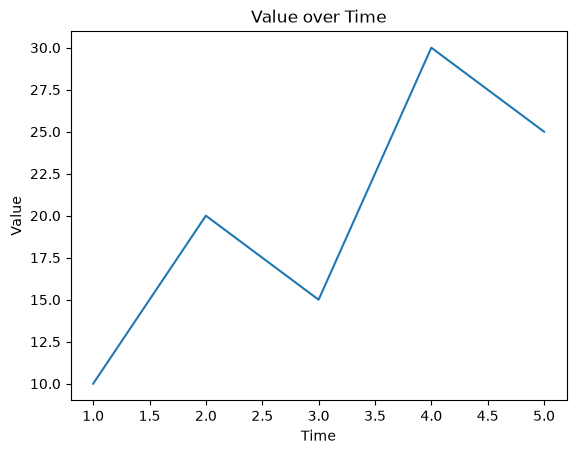

In [6]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 20, 15, 30, 25]

plt.plot(x, y)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Value over Time")
plt.show()

## 5.3 The Four Core Plot Types

| Plot | Function | Use It To Show |
|------|----------|-----------------|
| Line | `plt.plot()` | A trend or change over a continuous axis (e.g. time) |
| Scatter | `plt.scatter()` | The relationship between two numeric variables |
| Bar | `plt.bar()` | Comparison of a value across categories |
| Histogram | `plt.hist()` | The distribution (shape/spread) of a single variable |

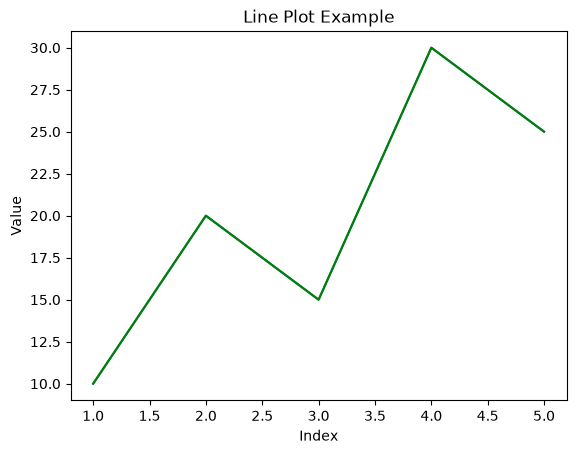

In [7]:
plt.plot(x, y)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Line Plot Example")
plt.plot(x, y, color="green")
plt.show()

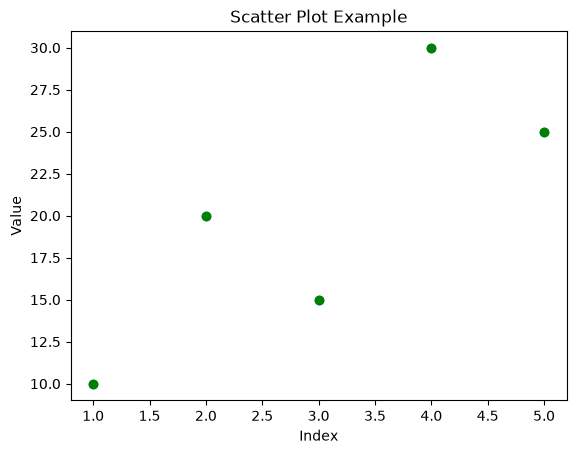

In [8]:
plt.scatter(x, y)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Scatter Plot Example")
plt.scatter(x, y, color="green")
plt.show()

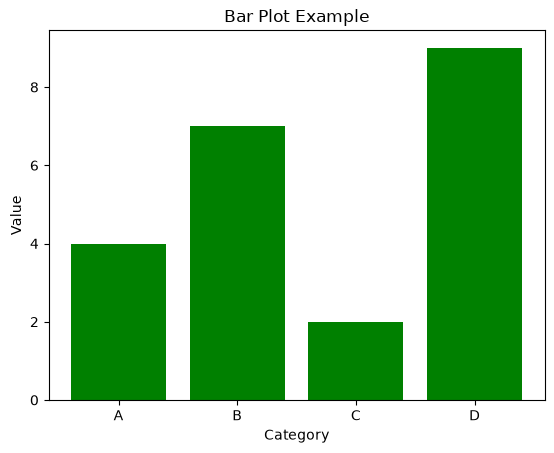

In [9]:
categories = ["A", "B", "C", "D"]
values = [4, 7, 2, 9]

plt.bar(categories, values)
plt.xlabel("Category")
plt.ylabel("Value")
plt.title("Bar Plot Example")
plt.bar(categories, values, color="green")
plt.show()

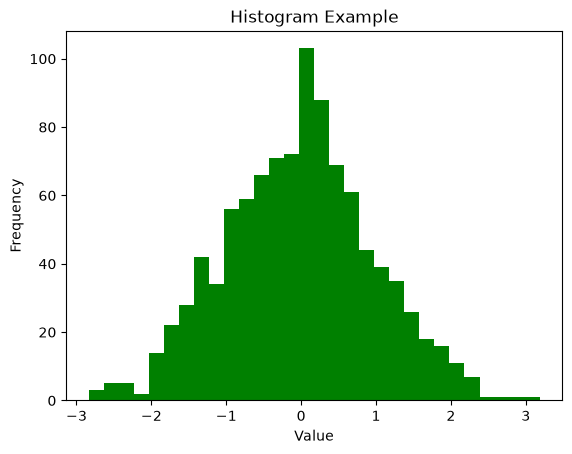

In [10]:
import numpy as np

data = np.random.randn(1000)

plt.hist(data, bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram Example")
plt.hist(data, bins=30, color="green")
plt.show()

## 5.4 Subplots

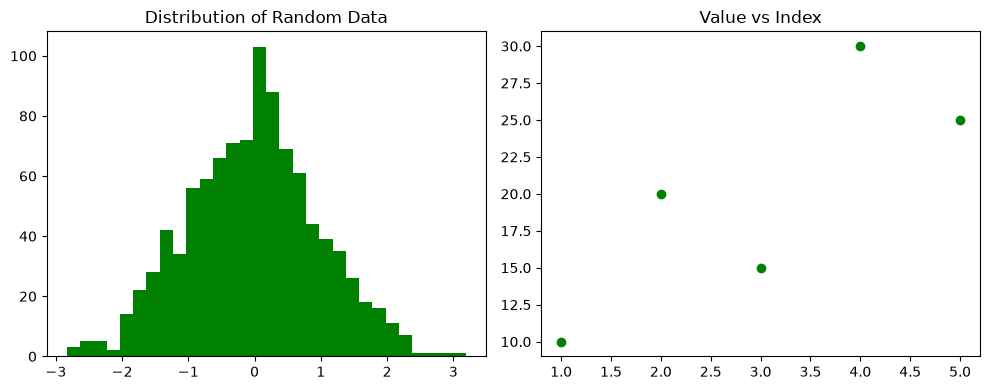

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(data, bins=30, color="green")
axes[0].set_title("Distribution of Random Data")

axes[1].scatter(x, y, color="green")
axes[1].set_title("Value vs Index")

plt.tight_layout()
plt.show()

## 5.5 Bringing It Together

NumPy computed mean: 30.0


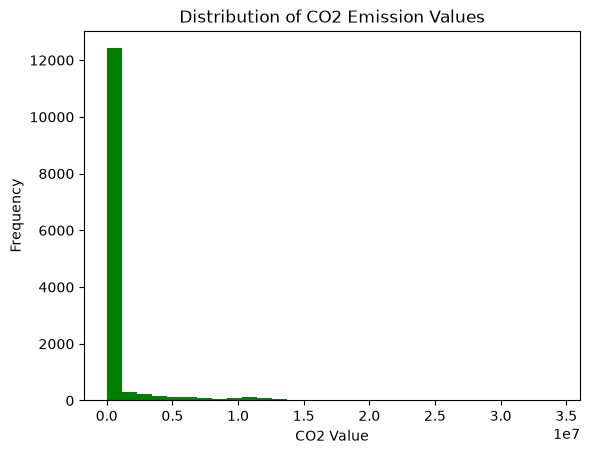

In [12]:
import pandas as pd

# 1. NumPy: a simple computation
sample_values = np.array([10, 20, 30, 40, 50])
mean_value = np.mean(sample_values)
print("NumPy computed mean:", mean_value)

# 2. Pandas: load and clean a dataset
combined_df = pd.read_csv("data.csv")
combined_df = combined_df.dropna()

# 3. Matplotlib: visualize it
plt.hist(combined_df["value"], bins=30, color="green")
plt.xlabel("CO2 Value")
plt.ylabel("Frequency")
plt.title("Distribution of CO2 Emission Values")
plt.show()

## 🧪 Hands-On Lab: Week 1 Integrated Mini-Notebook

### Step 1: Load and clean the dataset with Pandas

In [13]:
lab_df = pd.read_csv("data.csv")

print("Shape before cleaning:", lab_df.shape)
print("\nMissing values per column:\n", lab_df.isnull().sum())

lab_df = lab_df.dropna()

print("\nShape after cleaning:", lab_df.shape)

Shape before cleaning: (13953, 4)

Missing values per column:
 country_code    0
country_name    0
year            0
value           0
dtype: int64

Shape after cleaning: (13953, 4)


### Step 2: Use NumPy to compute a derived feature or summary statistic

In [14]:
# compute overall mean and standard deviation of CO2 values using NumPy
mean_co2 = np.mean(lab_df["value"])
std_co2 = np.std(lab_df["value"])

print("Mean CO2 value:", mean_co2)
print("Standard deviation:", std_co2)

# derived feature: how many standard deviations each value is from the mean (z-score)
lab_df["z_score"] = (lab_df["value"] - mean_co2) / std_co2
lab_df[["country_name", "year", "value", "z_score"]].head()

Mean CO2 value: 825498.3433543197
Standard deviation: 2788823.2709744964


,country_name,year,value,z_score
0,Aruba,1960,11092.675,-0.292025
1,Aruba,1961,11576.719,-0.291851
2,Aruba,1962,12713.489,-0.291444
3,Aruba,1963,12178.107,-0.291636
4,Aruba,1964,11840.743,-0.291757


### Step 3: Produce at least three labeled plots exploring the data


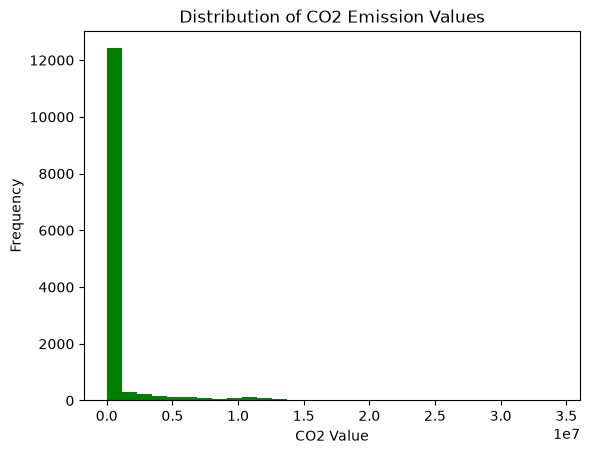

In [15]:
plt.hist(lab_df["value"], bins=30, color="green")
plt.xlabel("CO2 Value")
plt.ylabel("Frequency")
plt.title("Distribution of CO2 Emission Values")
plt.show()

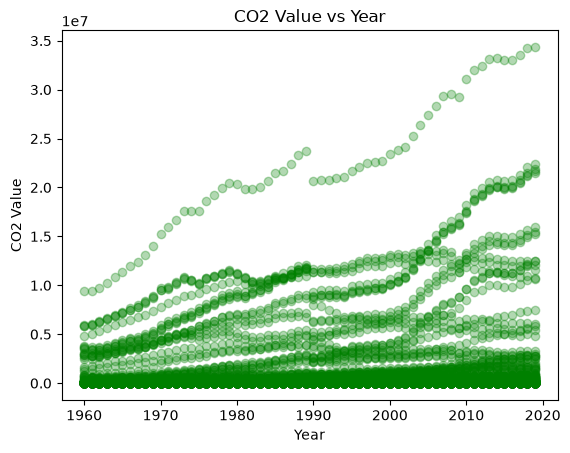

In [16]:
plt.scatter(lab_df["year"], lab_df["value"], color="green", alpha=0.3)
plt.xlabel("Year")
plt.ylabel("CO2 Value")
plt.title("CO2 Value vs Year")
plt.show()

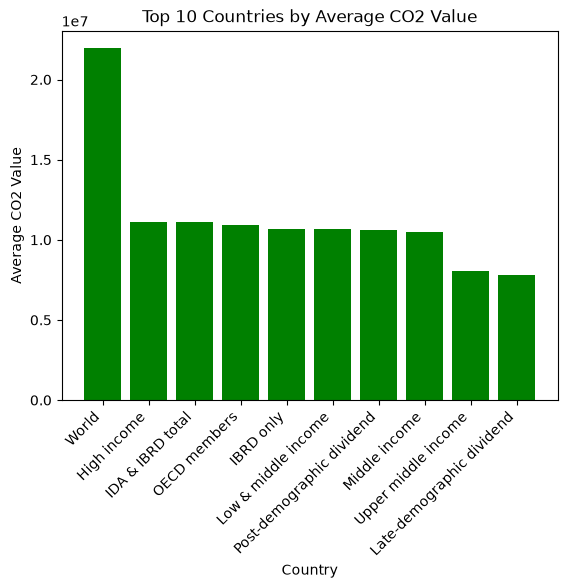

In [17]:
top10 = lab_df.groupby("country_name")["value"].mean().sort_values(ascending=False).head(10)

plt.bar(top10.index, top10.values, color="green")
plt.xlabel("Country")
plt.ylabel("Average CO2 Value")
plt.title("Top 10 Countries by Average CO2 Value")
plt.xticks(rotation=45, ha="right")
plt.show()

### Step 4: Interpretation of each visualization

**Histogram — Distribution of CO2 Emission Values:**
The distribution is heavily right-skewed — most records have relatively low
CO2 values, while a small number of records (large countries/regions) have
extremely high values, pulling the mean well above the median.

**Scatter — CO2 Value vs Year:**
There is no strong linear trend visible across all countries combined, since
values vary massively by country. However, the spread of high-value points
appears to widen slightly in more recent years, suggesting increasing
emissions among the highest-emitting entities over time.

**Bar — Top 10 Countries by Average CO2 Value:**
The top entities are dominated by large aggregated regions (e.g. "World",
"High income", "IDA & IBRD total", "OECD members") rather than individual
countries, reflecting that this dataset includes both country-level and
regional/group-level records. This highlights the need to separate
individual countries from aggregate groups for more precise country-level
analysis.